# **NLP**

In [1]:
import pandas as pd
import csv

# Load the TSV file
dataset = pd.read_csv(
    "Restaurant_Reviews.tsv",
    delimiter="\t",
    quoting=csv.QUOTE_NONE
)

dataset.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [2]:
# Import libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Download NLTK resources (Run once in Colab)
nltk.download('stopwords')

# Create an empty list to store cleaned reviews
corpus = []

# Create the stemmer object
ps = PorterStemmer()

# Clean each review
for i in range(len(dataset)):
    # Remove everything except letters
    review = re.sub('[^a-zA-Z]', ' ', dataset['Review'][i])

    # Convert to lowercase
    review = review.lower()

    # Split into individual words
    review = review.split()

    # Remove stopwords and perform stemming
    review = [
        ps.stem(word)
        for word in review
        if word not in set(stopwords.words('english'))
    ]

    # Join the words back into a sentence
    review = ' '.join(review)

    # Add the cleaned review to the corpus
    corpus.append(review)

[nltk_data] Downloading package stopwords to C:\Users\shubham
[nltk_data]     kharb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
print(corpus[:5])

['wow love place', 'crust good', 'tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price']


In [4]:
from sklearn.feature_extraction.text import CountVectorizer

# Create the Bag of Words model
cv = CountVectorizer(max_features=1500)

X = cv.fit_transform(corpus).toarray()

# Target variable
y = dataset['Liked'].values

In [5]:
print(X.shape)

(1000, 1500)


In [6]:
print(cv.get_feature_names_out())

['absolut' 'absolutley' 'accid' ... 'yum' 'yummi' 'zero']


In [7]:
print(cv.get_feature_names_out()[:20])

['absolut' 'absolutley' 'accid' 'accommod' 'accomod' 'accordingli'
 'account' 'ach' 'acknowledg' 'across' 'actual' 'ad' 'afford' 'afternoon'
 'ago' 'ahead' 'airlin' 'airport' 'ala' 'albondiga']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0
)

In [9]:
from sklearn.naive_bayes import GaussianNB

classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [10]:
y_pred = classifier.predict(X_test)

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)

print(cm)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

[[55 42]
 [12 91]]
Accuracy: 0.73


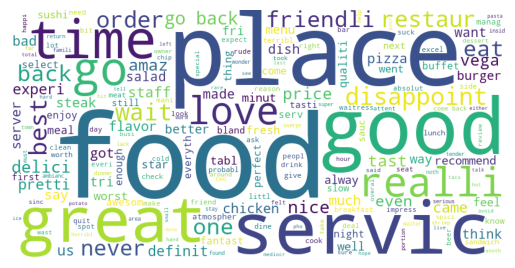

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(' '.join(corpus))

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [13]:
# Positive review
new_review = "I absolutely loved this restaurant. The food was amazing."

# Preprocess the review
new_review = re.sub('[^a-zA-Z]', ' ', new_review)
new_review = new_review.lower()
new_review = new_review.split()

new_review = [
    ps.stem(word)
    for word in new_review
    if word not in set(stopwords.words('english'))
]

new_review = ' '.join(new_review)

# Convert into Bag of Words
new_corpus = [new_review]
new_X_test = cv.transform(new_corpus).toarray()

# Predict
prediction = classifier.predict(new_X_test)

print(prediction)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

[1]
Positive Review 😊


In [15]:
import joblib
joblib.dump(cv, "count_vectorizer.pkl")
joblib.dump(classifier, "my_model.pkl")

print("Model saved successfully!")

Model saved successfully!
